# 🏛️ Metropolitan Museum of Art — Exploratory Data Analysis
**Project:** Cultural Pattern Discovery via Classical ML  
**Dataset:** [Met Open Access](https://github.com/metmuseum/openaccess) — `MetObjects.csv`  
**Goal:** Understand the structure of the dataset before building classifiers to predict curatorial departments and discover latent cultural patterns.

---
### Table of Contents
1. [Environment Setup](#1.-Environment-Setup)
2. [Load & Snapshot](#2.-Load-&-Snapshot)
3. [Missing Value Analysis](#3.-Missing-Value-Analysis)
4. [Target Variable: Department](#4.-Target-Variable:-Department)
5. [Temporal Analysis](#5.-Temporal-Analysis)
6. [Geographic & Cultural Analysis](#6.-Geographic-&-Cultural-Analysis)
7. [Artist Analysis](#7.-Artist-Analysis)
8. [Medium & Classification](#8.-Medium-&-Classification)
9. [Public Domain & Highlights](#9.-Public-Domain-&-Highlights)
10. [Feature Correlation & Candidate Features](#10.-Feature-Correlation-&-Candidate-Features)
11. [Key Takeaways & Next Steps](#11.-Key-Takeaways-&-Next-Steps)

---
## 1. Environment Setup

In [1]:
# ── Core ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Optional (word clouds) ────────────────────────────────
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("wordcloud not installed — skipping word-cloud cells. Run: pip install wordcloud")

# ── Display settings ──────────────────────────────────────
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

SEED = 42
np.random.seed(SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 2. Load & Snapshot

In [2]:
# ── Load dataset ──────────────────────────────────────────
# Download MetObjects.csv from:
#   https://github.com/metmuseum/openaccess/blob/master/MetObjects.csv
# Then update this path.

CSV_PATH = 'MetObjects.txt'   # <-- update if needed

df = pd.read_csv(
    CSV_PATH,
    dtype=str,           # read everything as string first
    low_memory=False,
    encoding='utf-8'
)

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape  : 484,956 rows × 54 columns
Memory : 1375.3 MB


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,Culture,Period,Dynasty,Reign,Portfolio,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL,Object Date,Object Begin Date,Object End Date,Medium,Dimensions,Credit Line,Geography Type,City,State,County,Country,Region,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,NaN,NaN,NaN,NaN,NaN,16429,Maker,,James Barton Longacre,"American, Delaware County, Pennsylvania 1794–1...",,"Longacre, James Barton",American,1794,1869,NaN,http://vocab.getty.edu/page/ulan/500011409,https://www.wikidata.org/wiki/Q3806459,1853,1853,1853,Gold,Dimensions unavailable,"Gift of Heinz L. Stoppelmann, 1979",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,NaN,NaN,NaN,NaN,NaN,107,Maker,,Christian Gobrecht,1785–1844,,"Gobrecht, Christian",American,1785,1844,NaN,http://vocab.getty.edu/page/ulan/500077295,https://www.wikidata.org/wiki/Q5109648,1901,1901,1901,Gold,Dimensions unavailable,"Gift of Heinz L. Stoppelmann, 1980",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1909–27,1909,1927,Gold,Diam. 11/16 in. (1.7 cm),"Gift of C. Ruxton Love Jr., 1967",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [3]:
# ── Column inventory ──────────────────────────────────────
print('All columns:\n')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')

All columns:

   1. Object Number
   2. Is Highlight
   3. Is Timeline Work
   4. Is Public Domain
   5. Object ID
   6. Gallery Number
   7. Department
   8. AccessionYear
   9. Object Name
  10. Title
  11. Culture
  12. Period
  13. Dynasty
  14. Reign
  15. Portfolio
  16. Constituent ID
  17. Artist Role
  18. Artist Prefix
  19. Artist Display Name
  20. Artist Display Bio
  21. Artist Suffix
  22. Artist Alpha Sort
  23. Artist Nationality
  24. Artist Begin Date
  25. Artist End Date
  26. Artist Gender
  27. Artist ULAN URL
  28. Artist Wikidata URL
  29. Object Date
  30. Object Begin Date
  31. Object End Date
  32. Medium
  33. Dimensions
  34. Credit Line
  35. Geography Type
  36. City
  37. State
  38. County
  39. Country
  40. Region
  41. Subregion
  42. Locale
  43. Locus
  44. Excavation
  45. River
  46. Classification
  47. Rights and Reproduction
  48. Link Resource
  49. Object Wikidata URL
  50. Metadata Date
  51. Repository
  52. Tags
  53. Tags AAT URL
  54.

In [4]:
# ── Type coercions ────────────────────────────────────────
bool_cols = ['Is Highlight', 'Is Timeline Work', 'Is Public Domain']
for c in bool_cols:
    df[c] = df[c].map({'True': True, 'False': False, True: True, False: False})

int_cols  = ['Object ID', 'Object Begin Date', 'Object End Date']
for c in int_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['AccessionYear'] = pd.to_numeric(df['AccessionYear'], errors='coerce')

print('Types after coercion:')
df[bool_cols + int_cols + ['AccessionYear']].dtypes

Types after coercion:


Is Highlight            bool
Is Timeline Work        bool
Is Public Domain        bool
Object ID              int64
Object Begin Date      int64
Object End Date        int64
AccessionYear        float64
dtype: object

In [5]:
# ── Quick numeric summary ─────────────────────────────────
df.describe(include='all').T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Object Number,484956,481656,62.635,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is Highlight,484956,2,False,482179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is Timeline Work,484956,2,False,476977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is Public Domain,484956,2,True,248472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Object ID,"484,956.00",NaN,NaN,NaN,"394,499.94","242,732.56",1.00,"212,379.75","374,771.50","570,971.25","900,748.00"
Gallery Number,49541,379,774,7547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,484956,19,Drawings and Prints,172630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccessionYear,"481,054.00",NaN,NaN,NaN,"1,955.81",35.58,"1,870.00","1,927.00","1,958.00","1,982.00","2,023.00"
Object Name,482690,28631,Print,102986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,456153,245800,Terracotta fragment of a kylix (drinking cup),6415,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Missing Value Analysis

> Understanding missingness is critical — high-NaN columns cannot be used as raw features without imputation or encoding strategies.

In [6]:
# ── Compute missingness ───────────────────────────────────
miss = (
    df.isnull().sum()
      .rename('n_missing')
      .to_frame()
      .assign(pct_missing=lambda x: 100 * x['n_missing'] / len(df))
      .sort_values('pct_missing', ascending=False)
)

# Treat empty strings as missing too
empty = (df == '').sum().rename('n_empty')
miss  = miss.join(empty)
miss['total_missing_pct'] = 100 * (miss['n_missing'] + miss['n_empty']) / len(df)

print(miss[miss['total_missing_pct'] > 0].to_string())

                         n_missing  pct_missing  n_empty  total_missing_pct
Metadata Date               484956       100.00        0             100.00
River                       482864        99.57        0              99.57
State                       482335        99.46        0              99.46
Locus                       477438        98.45        0              98.45
County                      476397        98.24        0              98.24
Reign                       473720        97.68        0              97.68
Locale                      469217        96.75        0              96.75
Excavation                  468385        96.58        0              96.58
Subregion                   462813        95.43        0              95.43
Dynasty                     461755        95.22        0              95.22
Rights and Reproduction     460427        94.94        0              94.94
Portfolio                   458442        94.53        0              94.53
Region      

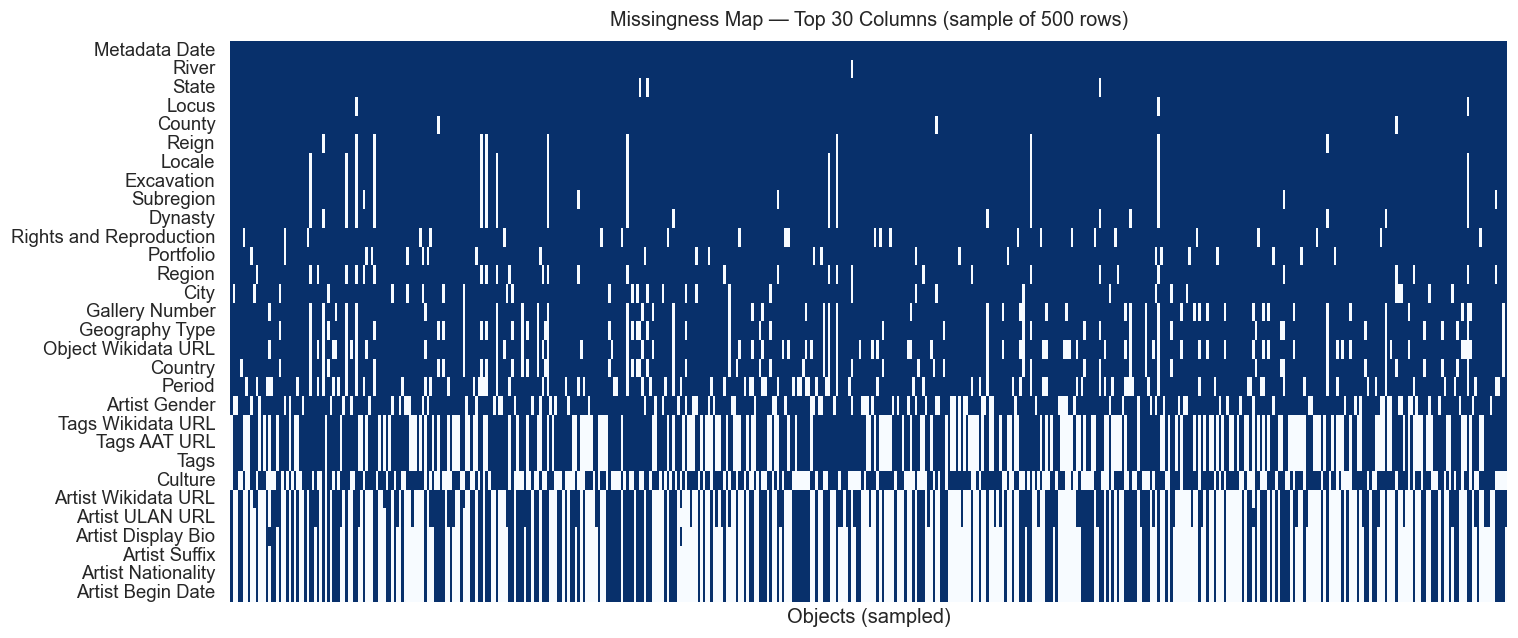

In [7]:
# ── Missingness heatmap (top-30 most-missing columns) ─────
top_miss = miss.head(30).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
sample  = df[top_miss].sample(min(500, len(df)), random_state=SEED).isnull()

sns.heatmap(
    sample.T, cmap='Blues', cbar=False,
    yticklabels=True, xticklabels=False, ax=ax
)
ax.set_title('Missingness Map — Top 30 Columns (sample of 500 rows)', fontsize=13, pad=10)
ax.set_xlabel('Objects (sampled)')
plt.tight_layout()
plt.show()

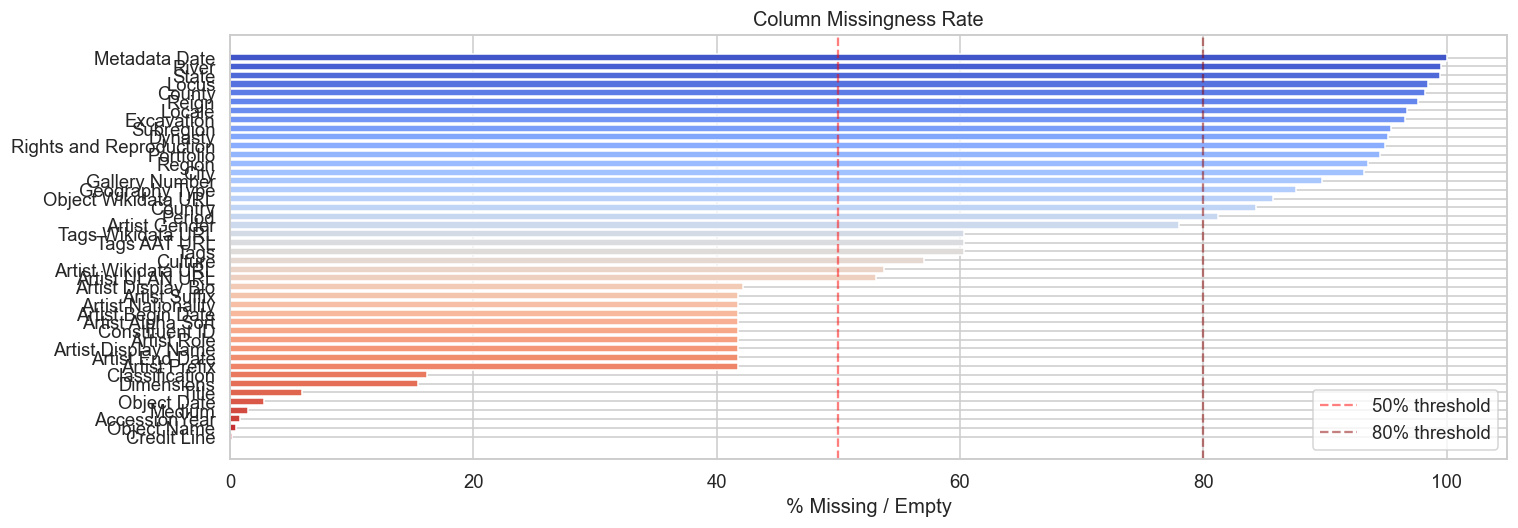


Columns with >80% missing: 19
Columns with >50% missing: 26
Columns with  <5% missing: 15


In [8]:
# ── Bar chart of missing rate ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cols    = miss[miss['total_missing_pct'] > 0].index
pcts    = miss.loc[cols, 'total_missing_pct']

bars = ax.barh(cols[::-1], pcts[::-1],
               color=sns.color_palette('coolwarm_r', len(cols)))
ax.axvline(50, ls='--', color='red', alpha=0.5, label='50% threshold')
ax.axvline(80, ls='--', color='darkred', alpha=0.5, label='80% threshold')
ax.set_xlabel('% Missing / Empty')
ax.set_title('Column Missingness Rate', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nColumns with >80% missing: {(miss['total_missing_pct'] > 80).sum()}")
print(f"Columns with >50% missing: {(miss['total_missing_pct'] > 50).sum()}")
print(f"Columns with  <5% missing: {(miss['total_missing_pct'] < 5).sum()}")

**Insight:** Columns like `Locus`, `Excavation`, `River`, `Dynasty`, `Reign` are expected to be sparse — they apply only to certain archaeological/ancient-art departments. We'll flag high-sparsity columns and treat their *presence/absence* as a binary feature.

---
## 4. Target Variable: Department

The classification target. Understanding its distribution reveals class imbalance — the #1 challenge for this project.

In [9]:
dept_counts = (
    df['Department']
      .value_counts(dropna=False)
      .reset_index()
)
dept_counts.columns = ['Department', 'Count']
dept_counts['Pct'] = 100 * dept_counts['Count'] / dept_counts['Count'].sum()

print(dept_counts.to_string(index=False))

                               Department  Count   Pct
                      Drawings and Prints 172630 35.60
   European Sculpture and Decorative Arts  43051  8.88
                              Photographs  37459  7.72
                                Asian Art  37000  7.63
                      Greek and Roman Art  33726  6.95
                        Costume Institute  31652  6.53
                             Egyptian Art  27969  5.77
                        The American Wing  18532  3.82
                              Islamic Art  15573  3.21
              Modern and Contemporary Art  14696  3.03
                           Arms and Armor  13623  2.81
Arts of Africa, Oceania, and the Americas  12367  2.55
                             Medieval Art   7142  1.47
                 Ancient Near Eastern Art   6223  1.28
                      Musical Instruments   5227  1.08
                       European Paintings   2626  0.54
                 Robert Lehman Collection   2586  0.53
          

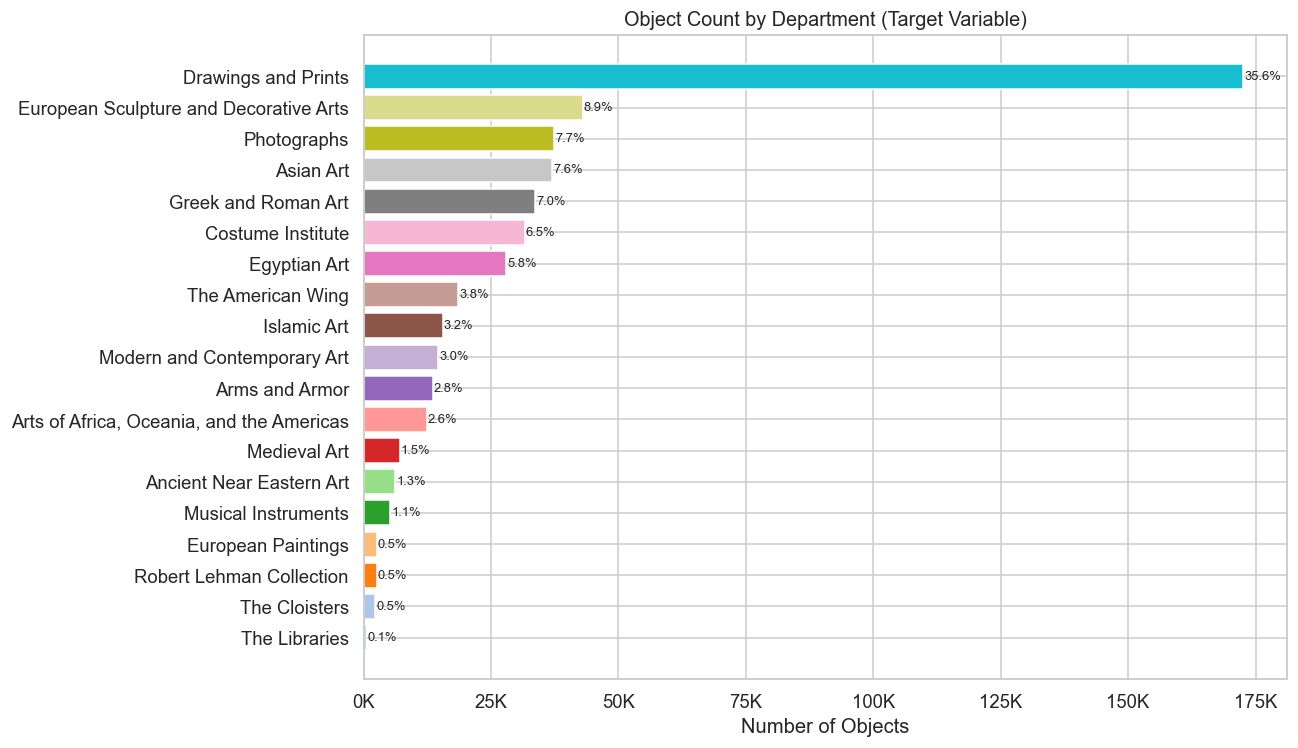

In [10]:
# ── Horizontal bar chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

palette  = sns.color_palette('tab20', len(dept_counts))
dept_counts_sorted = dept_counts.sort_values('Count')

bars = ax.barh(
    dept_counts_sorted['Department'],
    dept_counts_sorted['Count'],
    color=palette
)

for bar, pct in zip(bars, dept_counts_sorted['Pct']):
    ax.text(
        bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%', va='center', fontsize=8.5
    )

ax.set_xlabel('Number of Objects')
ax.set_title('Object Count by Department (Target Variable)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

In [11]:
# ── Class imbalance ratio ─────────────────────────────────
max_c = dept_counts['Count'].max()
min_c = dept_counts['Count'].min()
print(f'Largest  class : {dept_counts.iloc[0]["Department"]}  ({max_c:,})')
print(f'Smallest class : {dept_counts.iloc[-1]["Department"]} ({min_c:,})')
print(f'Imbalance ratio: {max_c / min_c:.1f}×')

Largest  class : Drawings and Prints  (172,630)
Smallest class : The Libraries (534)
Imbalance ratio: 323.3×


**Insight:** There is likely a severe class imbalance. Strategies to address this:
- Class-weighted loss / `class_weight='balanced'` in sklearn
- SMOTE oversampling for minority departments
- Macro-averaged F1 as the primary metric (not accuracy)

---
## 5. Temporal Analysis

Date range of objects (`Object Begin Date`, `Object End Date`) and museum acquisition year (`AccessionYear`).

In [12]:
# ── Compute object date span ──────────────────────────────
df['date_span'] = df['Object End Date'] - df['Object Begin Date']
df['date_midpoint'] = (df['Object Begin Date'] + df['Object End Date']) / 2

print('Object Begin Date statistics:')
print(df['Object Begin Date'].describe())
print('\nObject End Date statistics:')
print(df['Object End Date'].describe())

Object Begin Date statistics:
count    484,956.00
mean       1,303.91
std        1,710.26
min     -400,000.00
25%        1,535.00
50%        1,800.00
75%        1,891.00
max        5,000.00
Name: Object Begin Date, dtype: float64

Object End Date statistics:
count    484,956.00
mean       1,402.98
std        1,132.10
min     -240,000.00
25%        1,593.00
50%        1,840.00
75%        1,905.00
max        2,870.00
Name: Object End Date, dtype: float64


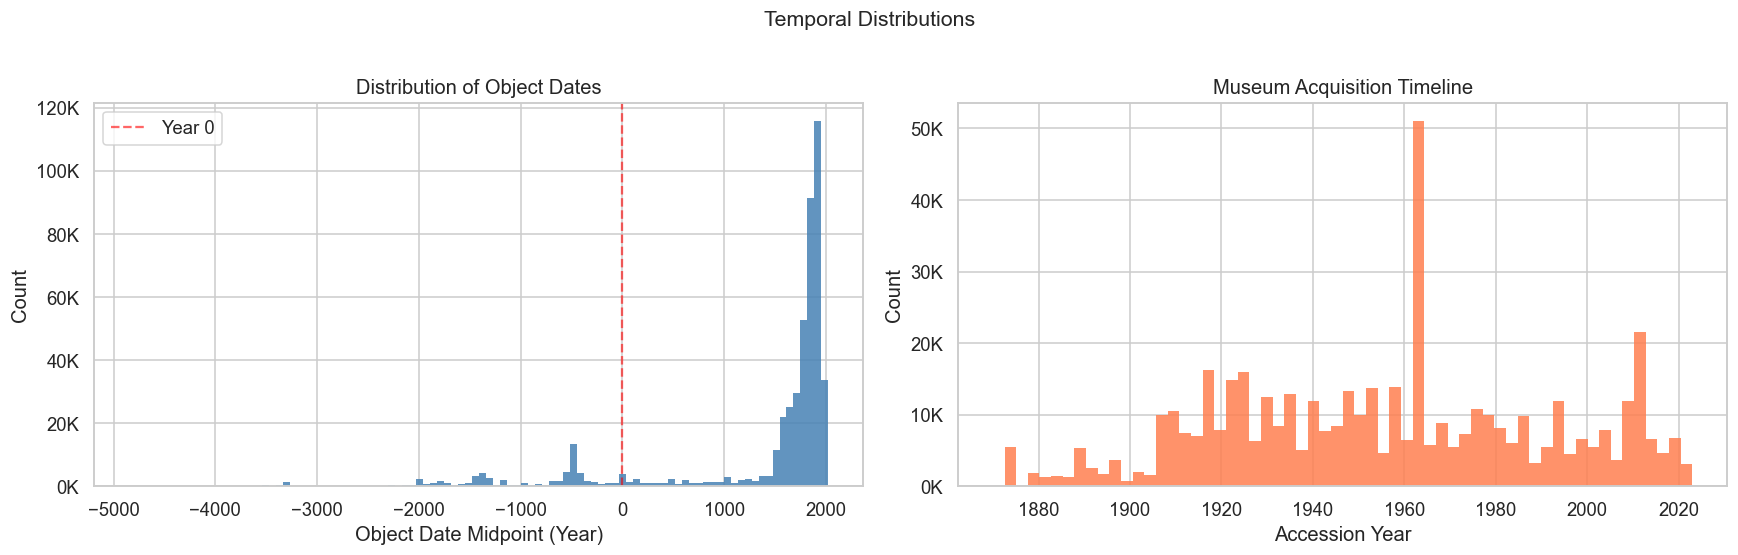

In [13]:
# ── Temporal distribution of objects ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ─ Midpoint histogram ─
ax = axes[0]
valid_mid = df['date_midpoint'].dropna()
# Clip extreme outliers for legibility
valid_mid = valid_mid[(valid_mid > -5000) & (valid_mid < 2030)]
ax.hist(valid_mid, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', ls='--', alpha=0.6, label='Year 0')
ax.set_xlabel('Object Date Midpoint (Year)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Object Dates')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend()

# ─ Accession Year histogram ─
ax = axes[1]
valid_acc = df['AccessionYear'].dropna()
valid_acc = valid_acc[(valid_acc >= 1870) & (valid_acc <= 2025)]
ax.hist(valid_acc, bins=60, color='coral', edgecolor='none', alpha=0.85)
ax.set_xlabel('Accession Year')
ax.set_ylabel('Count')
ax.set_title('Museum Acquisition Timeline')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Temporal Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

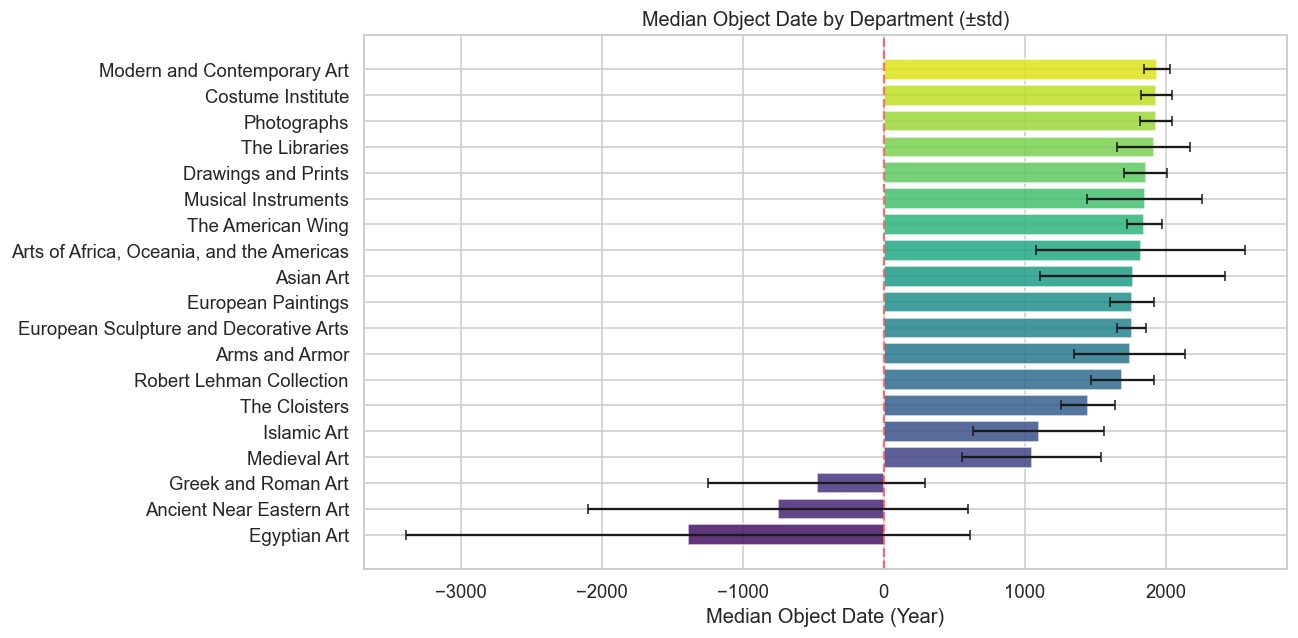

In [14]:
# ── Median object date by department ─────────────────────
dept_time = (
    df.groupby('Department')['date_midpoint']
      .agg(['median', 'std', 'count'])
      .rename(columns={'median': 'median_year', 'std': 'std_year', 'count': 'n'})
      .sort_values('median_year')
)
dept_time = dept_time[dept_time['n'] > 50]   # drop very sparse departments

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    dept_time.index,
    dept_time['median_year'],
    xerr=dept_time['std_year'].clip(upper=2000),
    color=sns.color_palette('viridis', len(dept_time)),
    alpha=0.85, capsize=3
)
ax.axvline(0, ls='--', color='red', alpha=0.5)
ax.set_xlabel('Median Object Date (Year)')
ax.set_title('Median Object Date by Department (±std)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ── Date span analysis ────────────────────────────────────
print('Date span (End – Begin) statistics:')
print(df['date_span'].describe())
print(f"\nObjects with date_span == 0 (point date): {(df['date_span'] == 0).sum():,}")
print(f"Objects with date_span >  500 years      : {(df['date_span'] > 500).sum():,}")

Date span (End – Begin) statistics:
count   484,956.00
mean         99.06
std         960.77
min      -5,000.00
25%           0.00
50%          10.00
75%          99.00
max     200,000.00
Name: date_span, dtype: float64

Objects with date_span == 0 (point date): 157,669
Objects with date_span >  500 years      : 9,856


**Feature engineering ideas from temporal analysis:**
- `date_midpoint` — numeric year estimate
- `date_span` — uncertainty window (archaeological vs. precisely dated)
- `is_ancient` — flag for objects before year 500
- `century` — discretized century bin
- `AccessionYear` — decade of acquisition

---
## 6. Geographic & Cultural Analysis

Columns: `Culture`, `Country`, `City`, `Region`, `Subregion`, `Geography Type`.

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\4252733616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


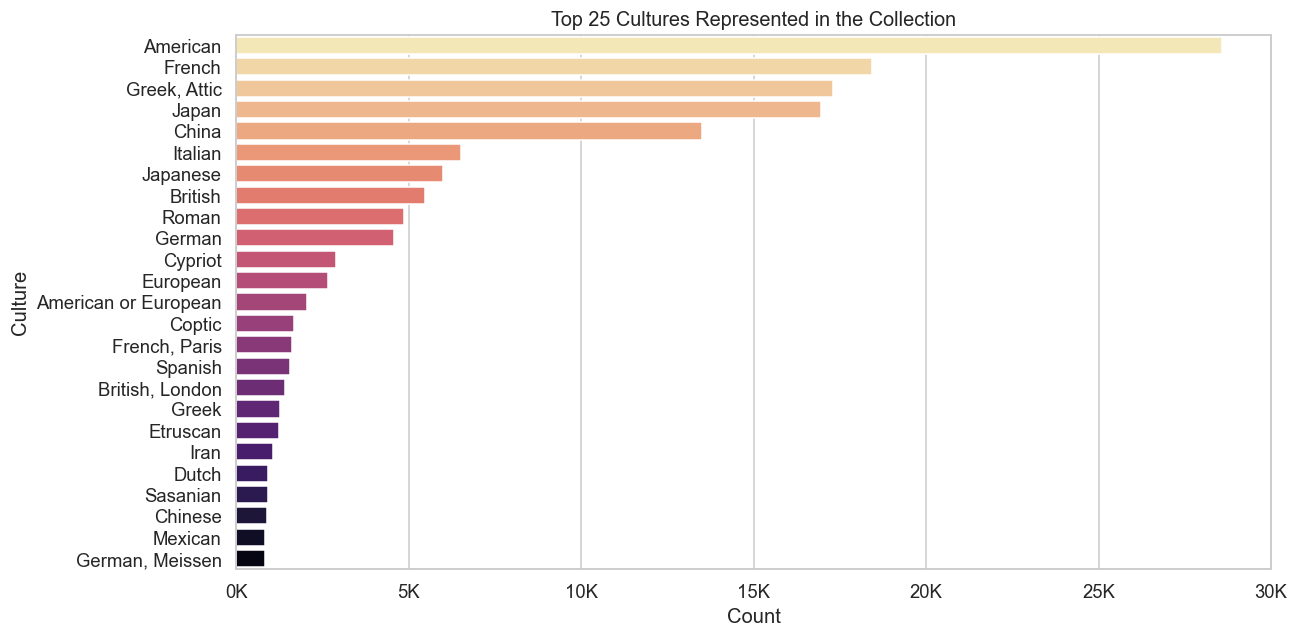

In [16]:
# ── Top cultures ──────────────────────────────────────────
top_cultures = df['Culture'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    x=top_cultures.values, y=top_cultures.index,
    palette='magma_r', ax=ax
)
ax.set_xlabel('Count')
ax.set_title('Top 25 Cultures Represented in the Collection', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\2741296623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


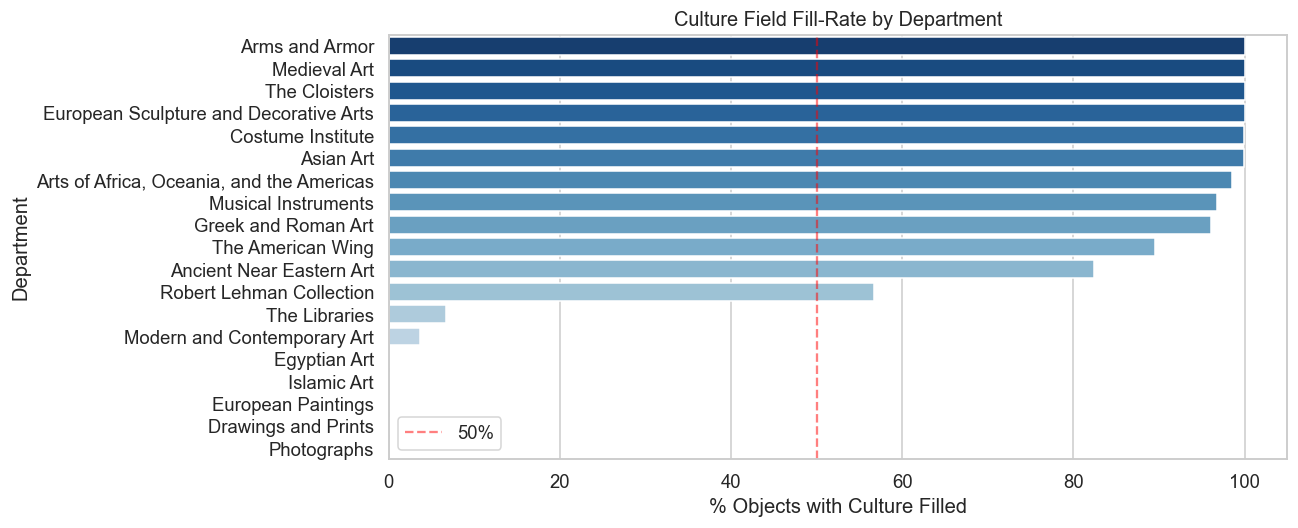

In [17]:
# ── Culture cardinality and fill-rate per department ──────
culture_fill = (
    df.groupby('Department')['Culture']
      .apply(lambda x: 100 * x.notna().sum() / len(x))
      .reset_index()
      .rename(columns={'Culture': 'culture_fill_pct'})
      .sort_values('culture_fill_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=culture_fill, x='culture_fill_pct', y='Department',
    palette='Blues_r', ax=ax
)
ax.axvline(50, ls='--', color='red', alpha=0.5, label='50%')
ax.set_xlabel('% Objects with Culture Filled')
ax.set_title('Culture Field Fill-Rate by Department', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\3007903077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


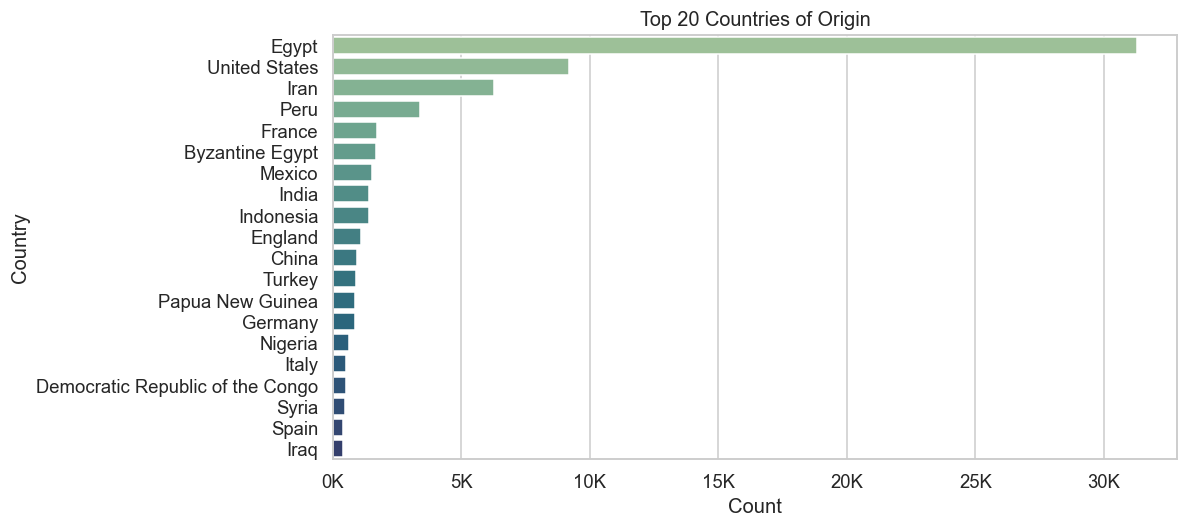

In [18]:
# ── Top countries of origin ───────────────────────────────
top_countries = df['Country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    x=top_countries.values, y=top_countries.index,
    palette='crest', ax=ax
)
ax.set_xlabel('Count')
ax.set_title('Top 20 Countries of Origin', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\2551407354.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


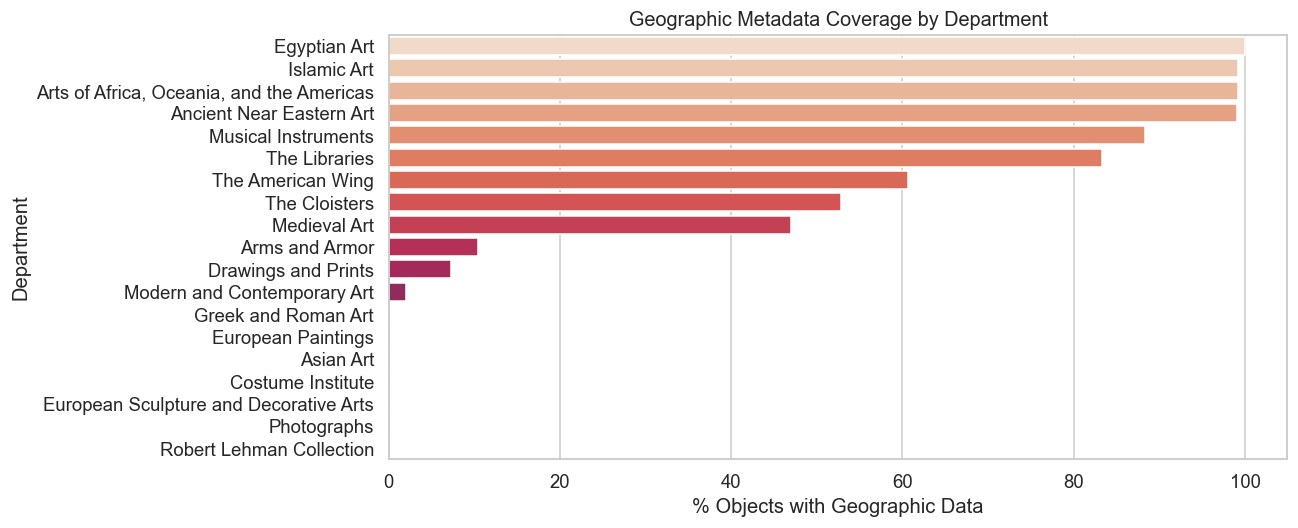

In [19]:
# ── Geo coverage: which departments are geo-tagged? ───────
geo_cols = ['Country', 'City', 'Region', 'Subregion']
df['has_geo'] = df[geo_cols].notna().any(axis=1)

geo_by_dept = (
    df.groupby('Department')['has_geo']
      .mean()
      .mul(100)
      .reset_index()
      .rename(columns={'has_geo': 'geo_pct'})
      .sort_values('geo_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=geo_by_dept, x='geo_pct', y='Department',
    palette='rocket_r', ax=ax
)
ax.set_xlabel('% Objects with Geographic Data')
ax.set_title('Geographic Metadata Coverage by Department', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Artist Analysis

Columns: `Artist Display Name`, `Artist Nationality`, `Artist Gender`, `Artist Begin Date`, `Artist End Date`.

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\2462416177.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


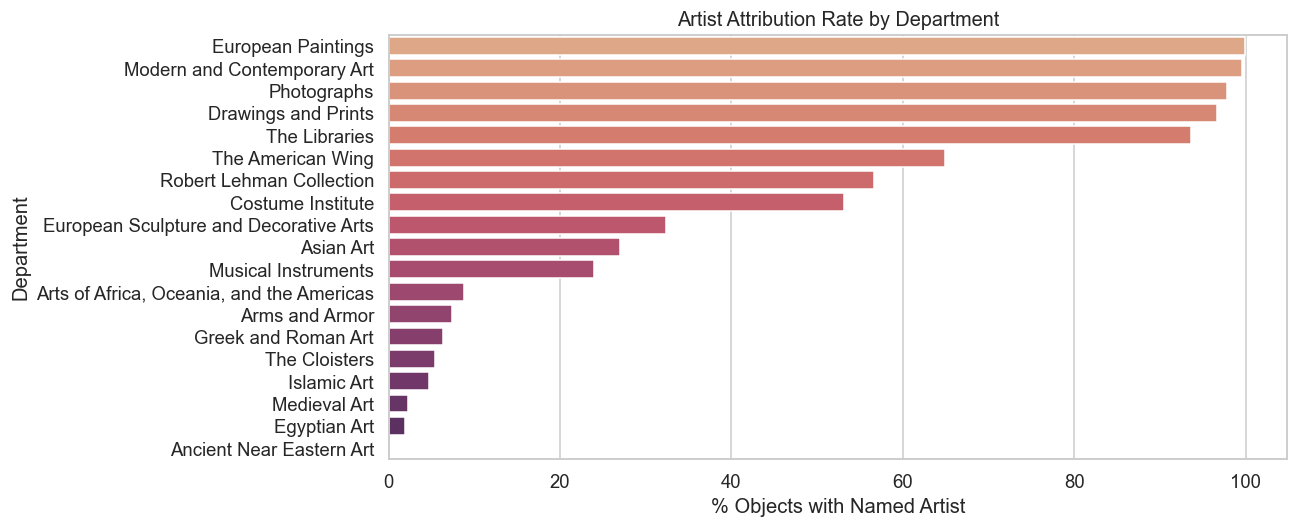

Overall: 58.3% of objects have a named artist.


In [20]:
# ── Known vs Unknown artist ───────────────────────────────
df['has_artist'] = df['Artist Display Name'].notna() & (df['Artist Display Name'] != '')

artist_fill_by_dept = (
    df.groupby('Department')['has_artist']
      .mean().mul(100)
      .reset_index()
      .rename(columns={'has_artist': 'artist_fill_pct'})
      .sort_values('artist_fill_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=artist_fill_by_dept, x='artist_fill_pct', y='Department',
    palette='flare', ax=ax
)
ax.set_xlabel('% Objects with Named Artist')
ax.set_title('Artist Attribution Rate by Department', fontsize=13)
plt.tight_layout()
plt.show()

pct_with = df['has_artist'].mean() * 100
print(f"Overall: {pct_with:.1f}% of objects have a named artist.")

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\4080639214.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nat.values, y=top_nat.index, palette='mako_r', ax=ax)


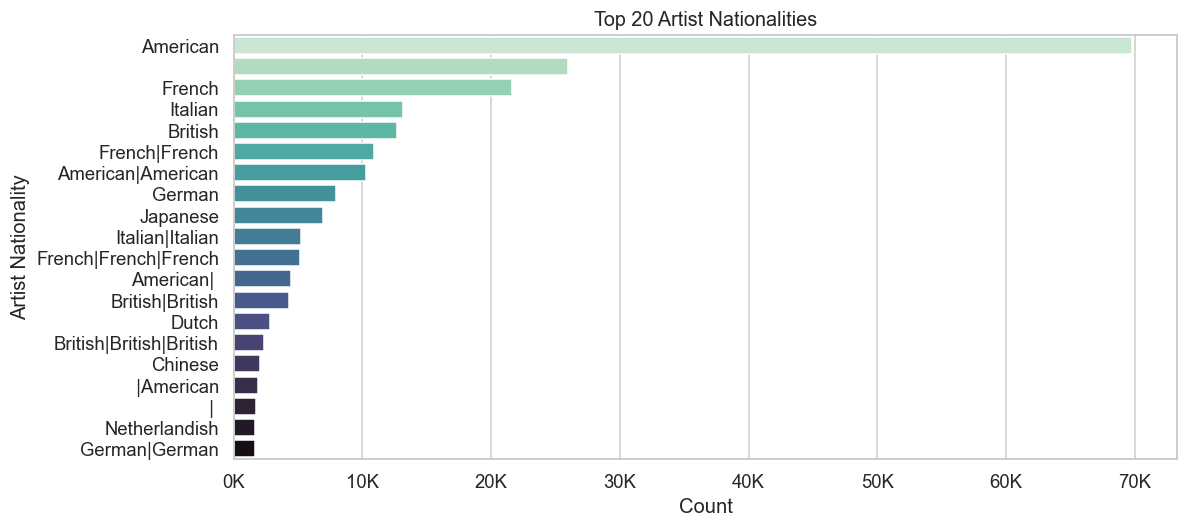

In [21]:
# ── Top nationalities ─────────────────────────────────────
top_nat = df['Artist Nationality'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=top_nat.values, y=top_nat.index, palette='mako_r', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Top 20 Artist Nationalities', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

Artist Gender distribution:
Artist Gender
NaN                                                                                                                                  378474
|                                                                                                                                     58718
||                                                                                                                                    21654
Female                                                                                                                                 8915
|||                                                                                                                                    6685
                                                                                                                                      ...  
Female||||||||||||||||||Female||||||||||||||||||||||||||||||||Female|||||||||||||||||||||||||||||||||||||||||         

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\740438393.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


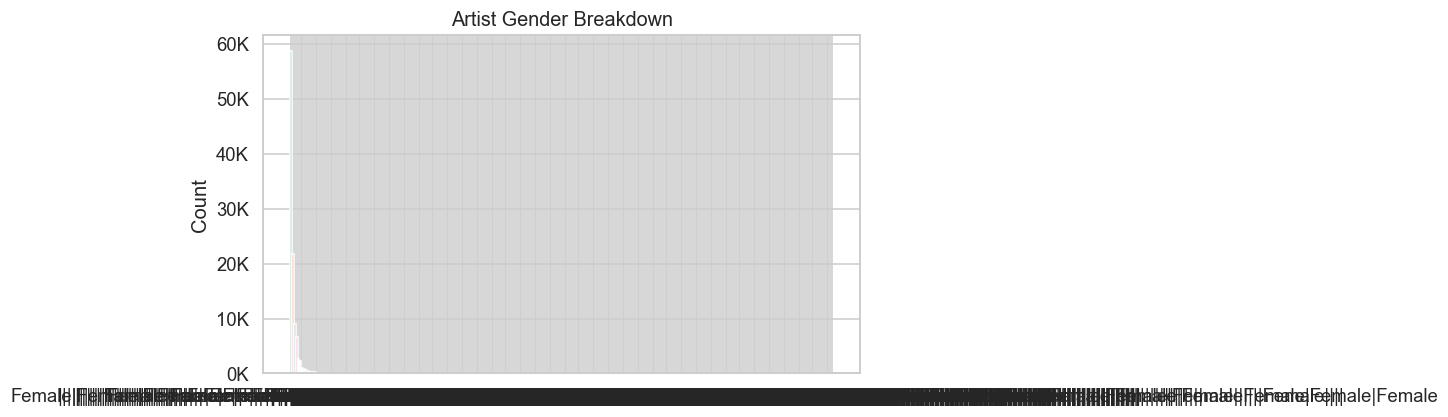

In [22]:
# ── Gender distribution (where filled) ───────────────────
gender_counts = df['Artist Gender'].value_counts(dropna=False)
print('Artist Gender distribution:')
print(gender_counts)

fig, ax = plt.subplots(figsize=(7, 4))
gender_clean = gender_counts[gender_counts.index.notna()]
ax.bar(gender_clean.index.astype(str), gender_clean.values,
       color=sns.color_palette('Set2'))
ax.set_ylabel('Count')
ax.set_title('Artist Gender Breakdown', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

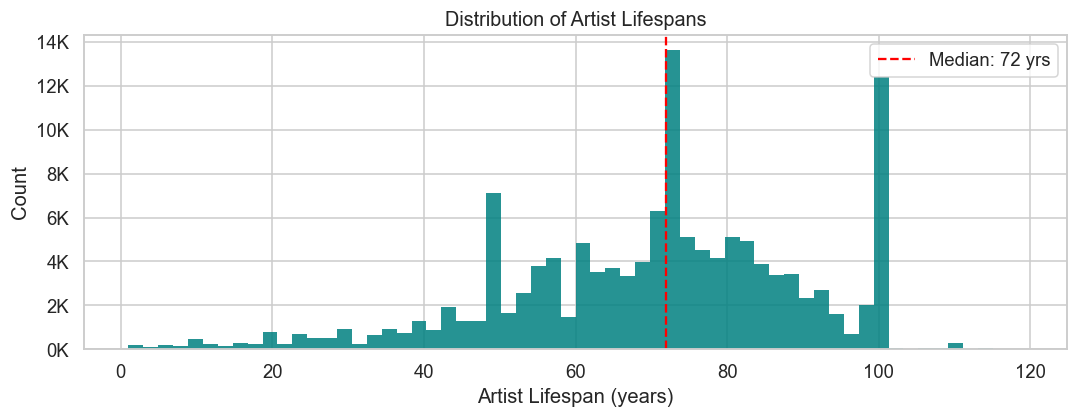

In [23]:
# ── Artist longevity (lifespan proxy) ────────────────────
df['artist_begin'] = pd.to_numeric(df['Artist Begin Date'], errors='coerce')
df['artist_end']   = pd.to_numeric(df['Artist End Date'],   errors='coerce')
df['artist_lifespan'] = df['artist_end'] - df['artist_begin']

valid_lifespan = df['artist_lifespan'][
    (df['artist_lifespan'] > 0) & (df['artist_lifespan'] < 120)
].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_lifespan, bins=60, color='teal', edgecolor='none', alpha=0.85)
ax.axvline(valid_lifespan.median(), color='red', ls='--', label=f'Median: {valid_lifespan.median():.0f} yrs')
ax.set_xlabel('Artist Lifespan (years)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Artist Lifespans', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

---
## 8. Medium & Classification

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\1402590081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cls.values, y=top_cls.index, palette='Spectral_r', ax=ax)


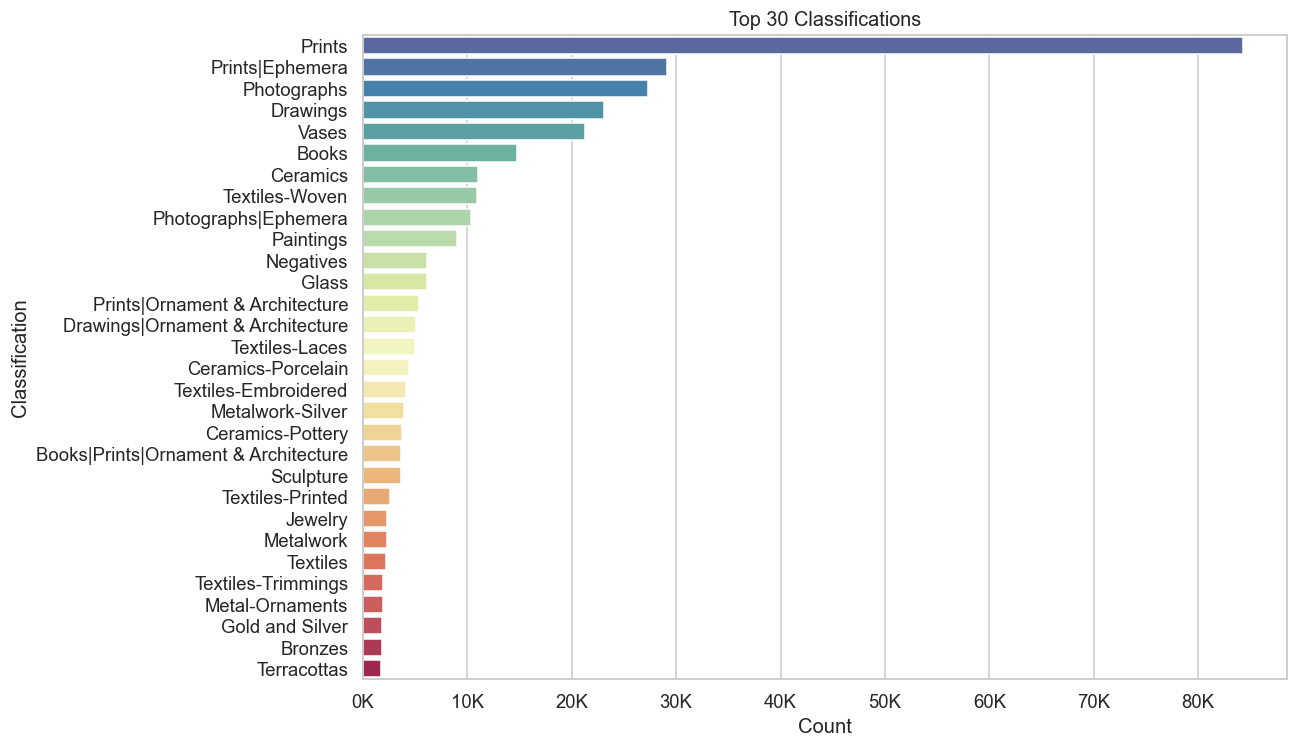


Unique Classifications: 1,244


In [24]:
# ── Top classifications ───────────────────────────────────
top_cls = df['Classification'].value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_cls.values, y=top_cls.index, palette='Spectral_r', ax=ax)
ax.set_xlabel('Count')
ax.set_title('Top 30 Classifications', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print(f"\nUnique Classifications: {df['Classification'].nunique():,}")

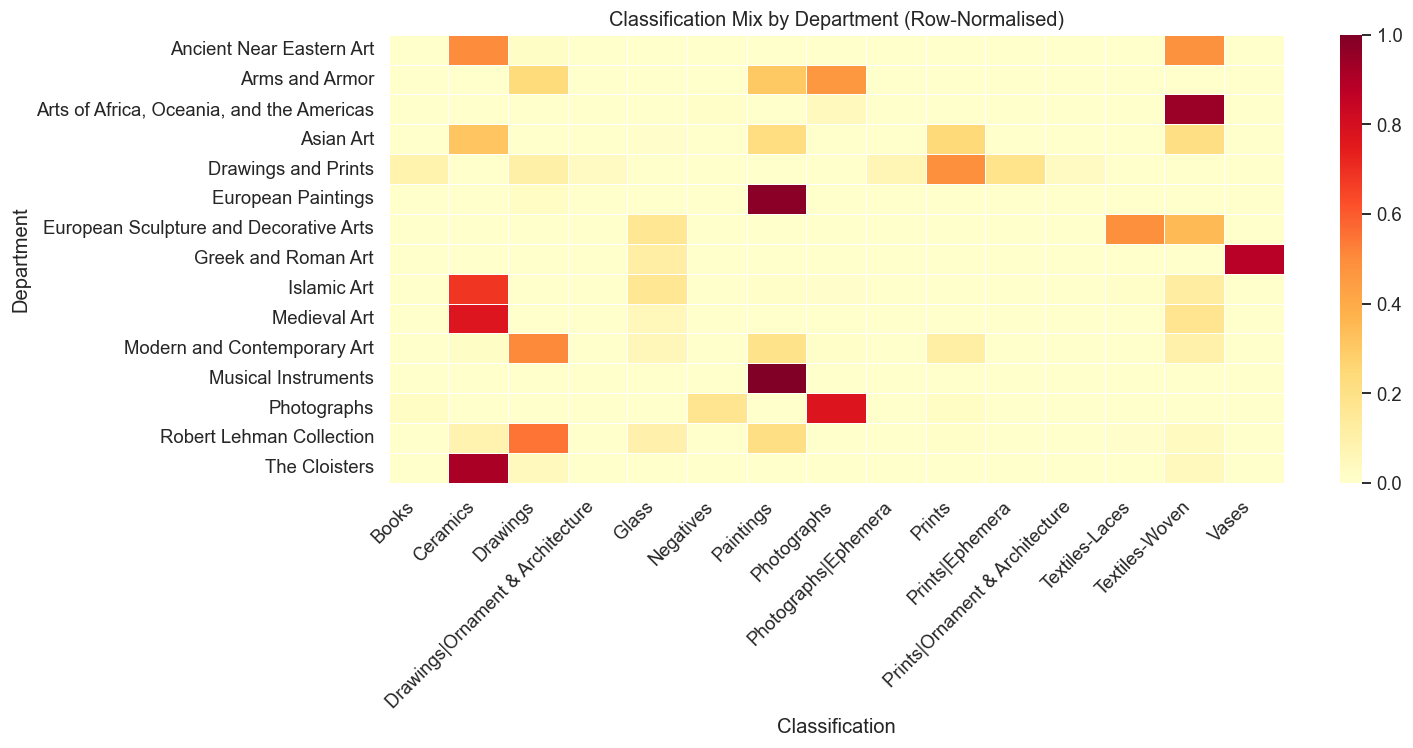

In [25]:
# ── Classification cardinality heatmap by department ─────
top_cls_list = df['Classification'].value_counts().head(15).index.tolist()
dept_cls = (
    df[df['Classification'].isin(top_cls_list)]
      .groupby(['Department', 'Classification'])
      .size()
      .unstack(fill_value=0)
)
# Normalize per department
dept_cls_norm = dept_cls.div(dept_cls.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    dept_cls_norm, annot=False, cmap='YlOrRd',
    linewidths=0.4, ax=ax, fmt='.2f'
)
ax.set_title('Classification Mix by Department (Row-Normalised)', fontsize=13)
ax.set_xlabel('Classification')
ax.set_ylabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

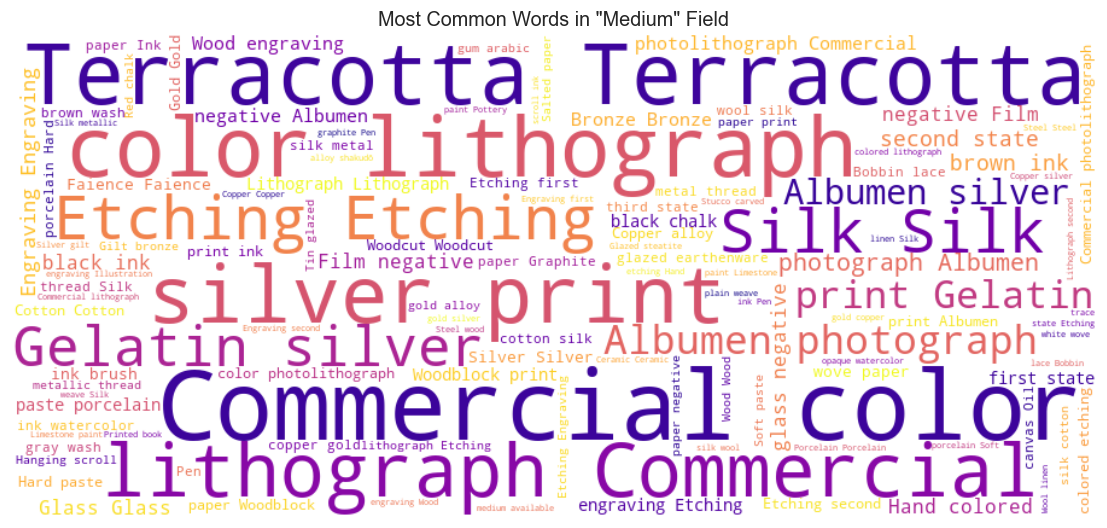

In [26]:
# ── Medium word cloud ─────────────────────────────────────
if HAS_WORDCLOUD:
    medium_text = ' '.join(df['Medium'].dropna().astype(str).tolist())
    wc = WordCloud(
        width=900, height=400, background_color='white',
        colormap='plasma', max_words=120, random_state=SEED
    ).generate(medium_text)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Most Common Words in "Medium" Field', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    top_medium = df['Medium'].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(x=top_medium.values, y=top_medium.index, palette='cubehelix', ax=ax)
    ax.set_xlabel('Count')
    ax.set_title('Top 20 Mediums', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 9. Public Domain & Highlights

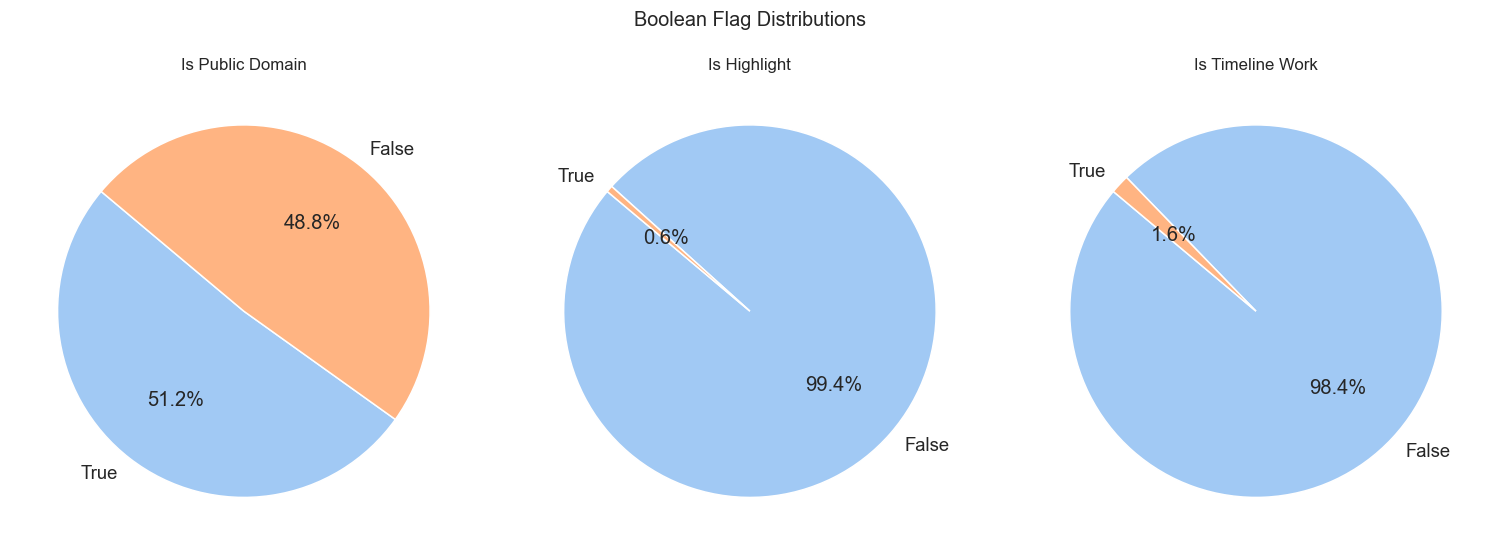

In [27]:
# ── Pie charts for boolean flags ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

flags = ['Is Public Domain', 'Is Highlight', 'Is Timeline Work']
for ax, flag in zip(axes, flags):
    vc = df[flag].value_counts(dropna=False)
    ax.pie(
        vc.values,
        labels=[str(v) for v in vc.index],
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),
        startangle=140
    )
    ax.set_title(flag, fontsize=11)

fig.suptitle('Boolean Flag Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\55967960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highlight_dept, x='highlight_pct', y='Department',


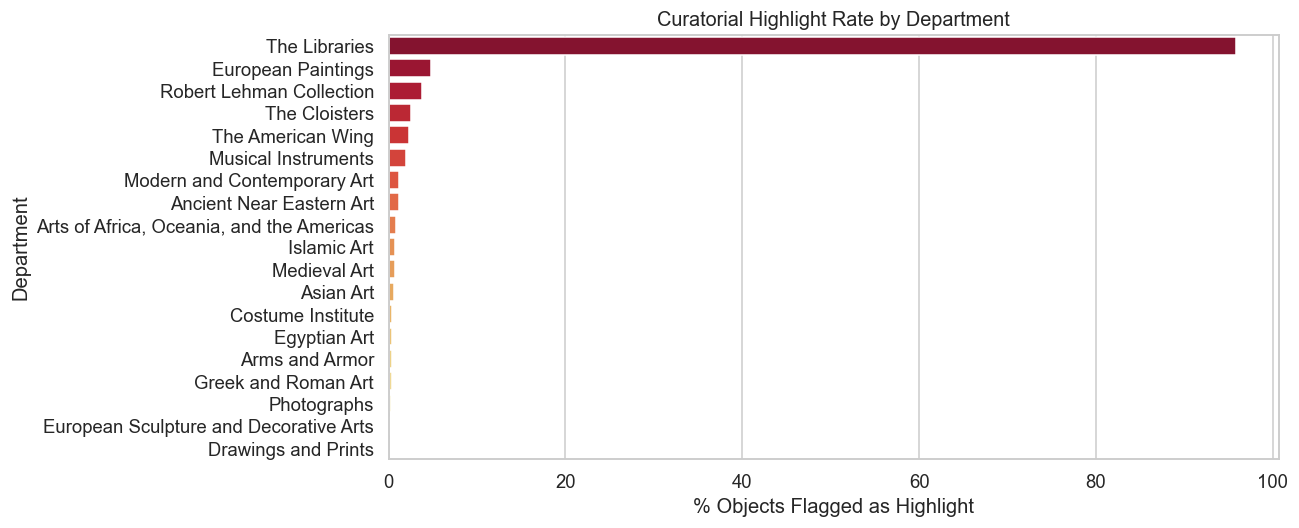

In [28]:
# ── Highlight rate per department ─────────────────────────
highlight_dept = (
    df.groupby('Department')['Is Highlight']
      .mean().mul(100)
      .reset_index()
      .rename(columns={'Is Highlight': 'highlight_pct'})
      .sort_values('highlight_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=highlight_dept, x='highlight_pct', y='Department',
            palette='YlOrRd_r', ax=ax)
ax.set_xlabel('% Objects Flagged as Highlight')
ax.set_title('Curatorial Highlight Rate by Department', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Feature Correlation & Candidate Features

Identify which engineered features are most predictive of the target before building models.

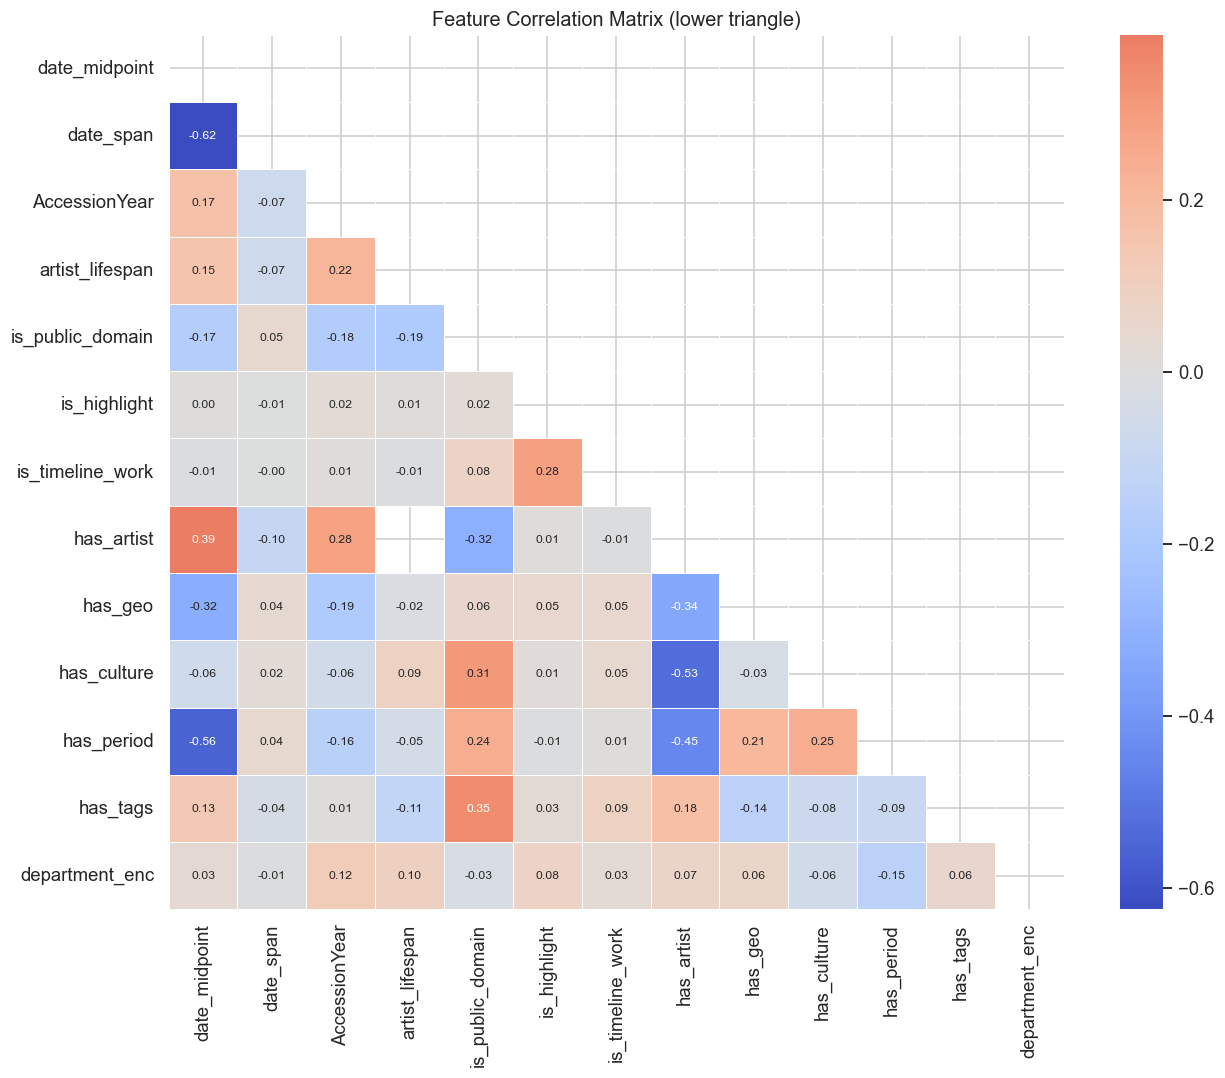

In [29]:
from sklearn.preprocessing import LabelEncoder

# ── Build a lightweight feature frame ────────────────────
feat = pd.DataFrame(index=df.index)

# Numeric
feat['date_midpoint']   = df['date_midpoint']
feat['date_span']       = df['date_span']
feat['AccessionYear']   = df['AccessionYear']
feat['artist_lifespan'] = df['artist_lifespan']

# Boolean → int
feat['is_public_domain'] = df['Is Public Domain'].astype(float)
feat['is_highlight']     = df['Is Highlight'].astype(float)
feat['is_timeline_work'] = df['Is Timeline Work'].astype(float)

# Presence flags
feat['has_artist']       = df['has_artist'].astype(float)
feat['has_geo']          = df['has_geo'].astype(float)
feat['has_culture']      = df['Culture'].notna().astype(float)
feat['has_period']       = df['Period'].notna().astype(float)
feat['has_tags']         = df['Tags'].notna().astype(float)

# Label-encode target
le_dept = LabelEncoder()
feat['department_enc'] = le_dept.fit_transform(df['Department'].fillna('Unknown'))

feat_corr = feat.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\Dishaa\AppData\Local\Temp\ipykernel_16592\2131712034.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis', ax=ax)


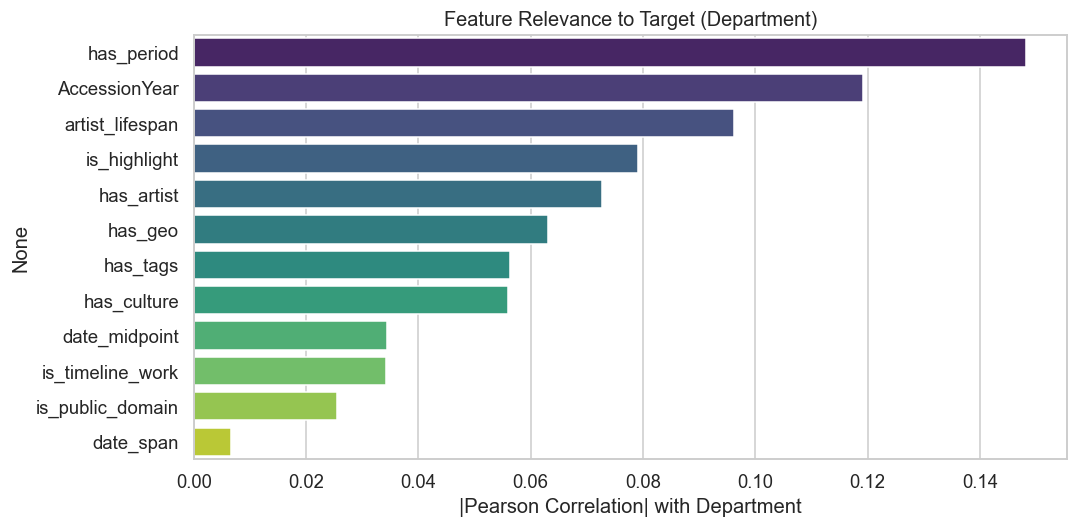


Top features by correlation with Department:
has_period         0.15
AccessionYear      0.12
artist_lifespan    0.10
is_highlight       0.08
has_artist         0.07
has_geo            0.06
has_tags           0.06
has_culture        0.06
date_midpoint      0.03
is_timeline_work   0.03
is_public_domain   0.03
date_span          0.01


In [30]:
# ── Correlation with target ───────────────────────────────
target_corr = (
    feat_corr['department_enc']
      .drop('department_enc')
      .abs()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis', ax=ax)
ax.set_xlabel('|Pearson Correlation| with Department')
ax.set_title('Feature Relevance to Target (Department)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop features by correlation with Department:')
print(target_corr.to_string())

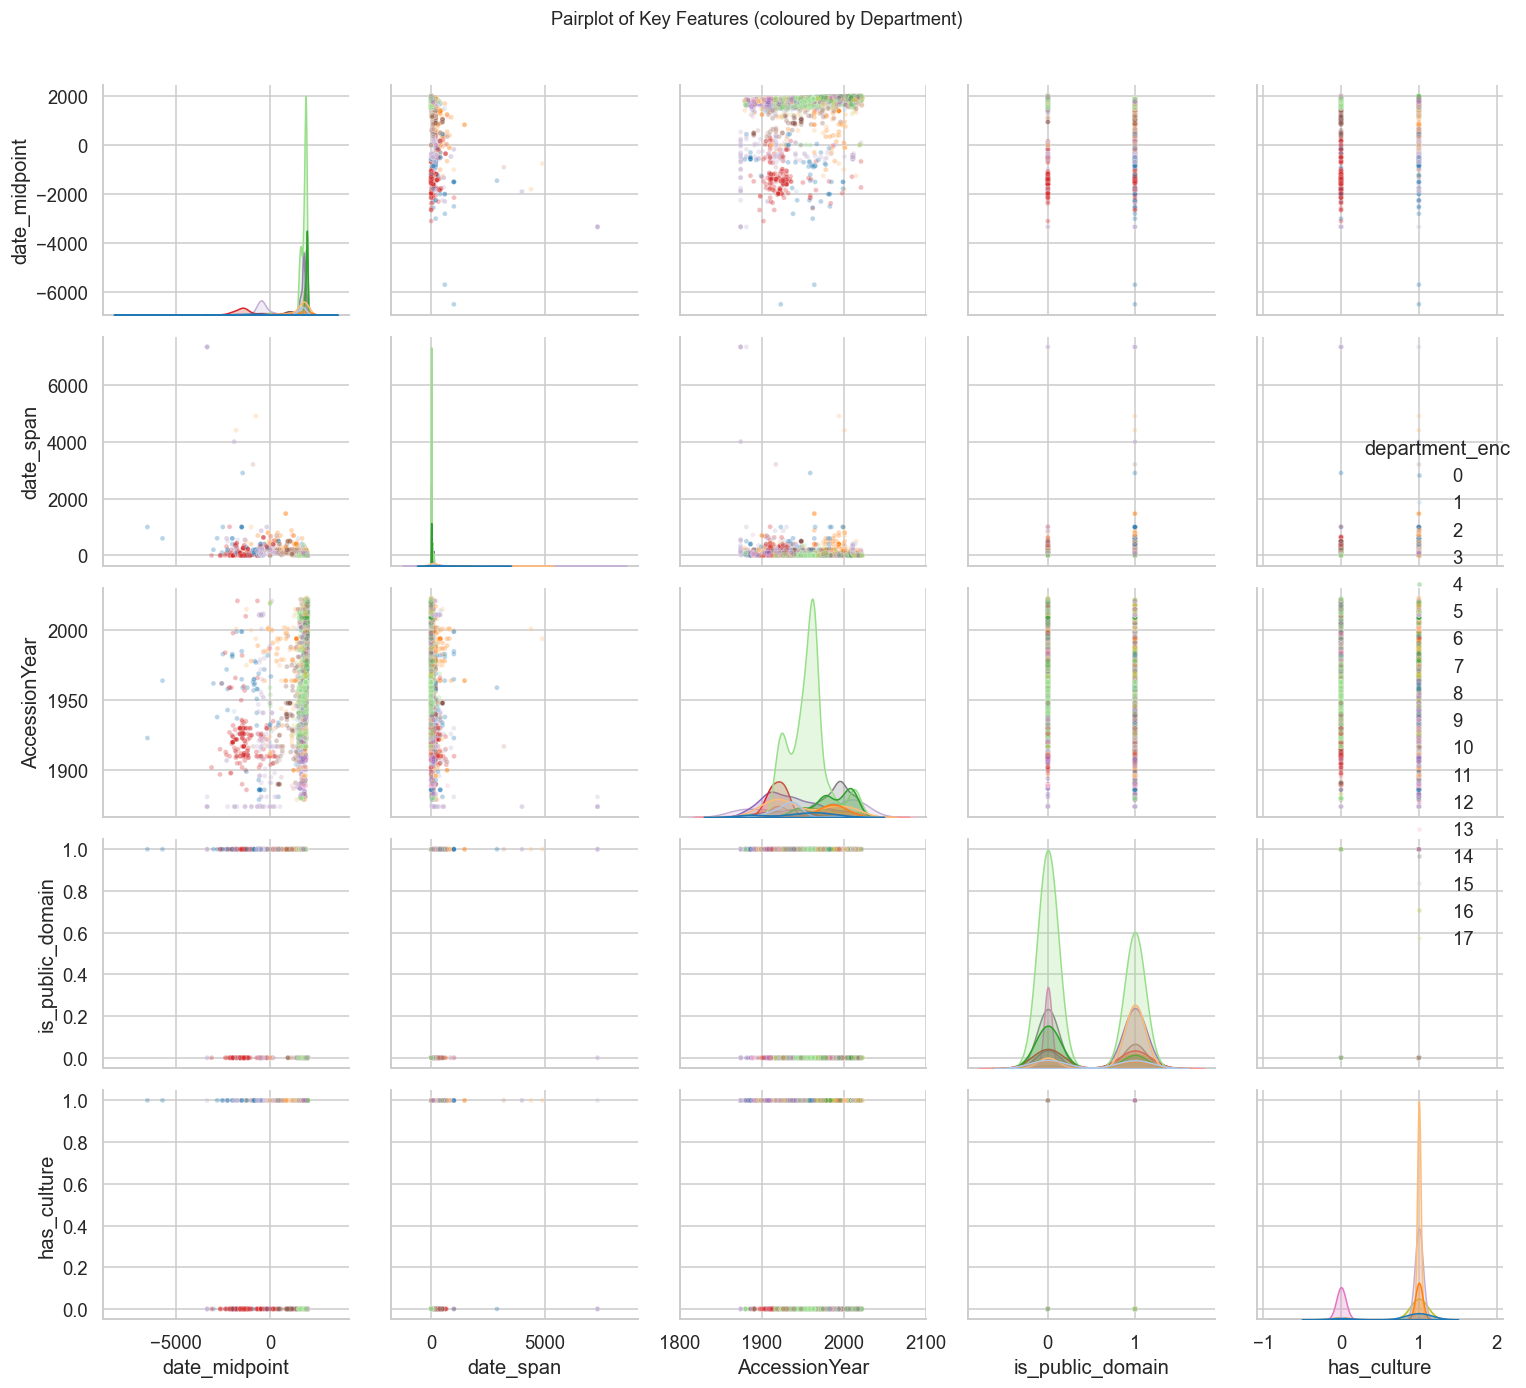

In [31]:
# ── Pair plot of top numeric features ─────────────────────
# Sample for speed
plot_cols = ['date_midpoint', 'date_span', 'AccessionYear', 'is_public_domain', 'has_culture']
sample_df = feat[plot_cols + ['department_enc']].dropna().sample(min(3000, len(feat)), random_state=SEED)

pair_g = sns.pairplot(
    sample_df, hue='department_enc', vars=plot_cols,
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde', palette='tab20'
)
pair_g.fig.suptitle('Pairplot of Key Features (coloured by Department)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

---
## 11. Key Takeaways & Next Steps

### 📌 EDA Summary

| Finding | Implication |
|---|---|
| **Severe class imbalance** across departments | Use `class_weight='balanced'`, macro-F1 as metric |
| **High missingness** in archaeological cols (`Dynasty`, `Reign`, `Locus`) | Use presence/absence as binary feature |
| **Date midpoint** separates departments well (Ancient Art vs Modern) | Strong engineered numeric feature |
| **Culture, Classification** are high-cardinality strings | Encode with frequency or target encoding |
| **Is Public Domain** correlates with time period and department | Good low-noise boolean feature |
| **Artist attribution rate** varies massively by department | Predictive binary feature |
| **Geographic metadata** largely absent for Asian, costume depts | Geo presence as feature; fill-rate matters |

### 🔧 Feature Engineering Roadmap

```python
# Tier 1 — high signal, low noise
['date_midpoint', 'date_span', 'is_public_domain', 'AccessionYear']

# Tier 2 — presence flags
['has_artist', 'has_culture', 'has_period', 'has_geo', 'has_tags']

# Tier 3 — high-cardinality categoricals (need encoding)
['Culture', 'Classification', 'Artist Nationality', 'Country']

# Tier 4 — text-derived (TF-IDF or embeddings)
['Medium', 'Tags', 'Title']
```

### 🤖 Modelling Roadmap

1. **Baseline:** Logistic Regression on Tier 1+2 features  
2. **Tree-based:** Random Forest / Gradient Boosting (handles mixed types well)  
3. **Clustering:** KMeans / HDBSCAN on encoded cultural-metadata features to discover latent cultural groups  
4. **Dimensionality reduction:** UMAP on high-cardinality categorical embeddings  
5. **Evaluation:** Macro-F1, confusion matrix, SHAP feature importance

---
*Generated as part of the Cultural Pattern Discovery ML portfolio project — Met Open Access dataset.*